# So sánh 3 phương pháp OOD Detection: MSP vs KNN vs ViM
**Protocol:** ID = CIFAR-10 · Near-OOD = CIFAR-100 · Far-OOD = MNIST · Model: WRN-40-2 (cross-entropy)

Notebook này **chỉ load kết quả đã lưu** (CSV + NPZ). Không retrain, không sửa implementation, không tạo dữ liệu thiếu.

**Quy ước score (đã kiểm chứng bằng cách so AUROC tính lại từ raw score với AUROC trong CSV, xem Section 3b):**

| Method | Raw score | Hướng | OOD-score dùng cho ROC/failure (positive = OOD) |
|---|---|---|---|
| MSP | max softmax prob | cao = ID-like | `1 - MSP` |
| KNN | khoảng cách KNN | cao = OOD-like | dùng trực tiếp |
| ViM | ViM score | cao = OOD-like | dùng trực tiếp |

Việc đổi dấu chỉ làm ở lớp comparison/visualization, raw score không bị sửa.

## 1. Imports

In [ ]:
import os, re, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)

METHODS  = ['MSP', 'KNN', 'ViM']
NEAR, FAR = 'CIFAR-100 (Near-OOD)', 'MNIST (Far-OOD)'
DATASETS = [NEAR, FAR]
COLORS   = {'MSP': '#4C72B0', 'KNN': '#DD8452', 'ViM': '#55A868'}

## 2. Load result files

In [ ]:
DATA_DIR = Path(os.environ.get('OOD_DATA_DIR', '/content'))
OUT_DIR  = Path(os.environ.get('OOD_OUT_DIR', '/content/ood_comparison_outputs'))
OUT_DIR.mkdir(parents=True, exist_ok=True)

FILES = {'MSP': ('msp_results.csv', 'msp_scores.npz'),
         'KNN': ('KNN_results.csv', 'KNN_scores.npz'),
         'ViM': ('ViM_results.csv', 'ViM_scores.npz')}

needed = [f for pair in FILES.values() for f in pair]
if not all((DATA_DIR / f).exists() for f in needed):
    try:
        from google.colab import files   # chi chay tren Colab
        print('Thieu file trong', DATA_DIR, '-> hay upload 6 file:', needed)
        files.upload()
        DATA_DIR = Path('.')
    except ImportError:
        raise FileNotFoundError(f'Khong tim thay du 6 file trong {DATA_DIR}')

raw_csv = {m: pd.read_csv(DATA_DIR / FILES[m][0], encoding='utf-8-sig') for m in METHODS}
raw_npz = {m: np.load(DATA_DIR / FILES[m][1], allow_pickle=True) for m in METHODS}
print('Loaded OK from', DATA_DIR)

Loaded OK from /content


## 3. Inspect CSV columns và NPZ keys (không giả định tên)

In [ ]:
for m in METHODS:
    print('='*80); print(m, '- CSV columns:', list(raw_csv[m].columns)); display(raw_csv[m])
for m in METHODS:
    print('='*80); print(m, '- NPZ keys:')
    for k in raw_npz[m].files:
        a = raw_npz[m][k]
        if a.ndim == 0: print(f'  {k:22s} scalar -> {a.item()}')
        else: print(f'  {k:22s} shape={a.shape} dtype={a.dtype} min={a.min():.4f} max={a.max():.4f} '
                    f'NaN={np.isnan(a).sum()} Inf={np.isinf(a).sum()}')

MSP - CSV columns: ['Model', 'ID dataset', 'n ID', 'ID accuracy (%)', 'Tập dữ liệu test', 'n OOD', 'AUROC ↑ (%)', 'AUPR-IN ↑ (%)', 'AUPR-OUT ↑ (%)', 'FPR95TPR ↓ (%)', 'AUTC ↓ (%)']


,Model,ID dataset,n ID,ID accuracy (%),Tập dữ liệu test,n OOD,AUROC ↑ (%),AUPR-IN ↑ (%),AUPR-OUT ↑ (%),FPR95TPR ↓ (%),AUTC ↓ (%)
0,wrn-40-2/cifar10/crossentropy,CIFAR-10 test,10000,94.84,CIFAR-100 (near-OOD),10000,87.8255,88.4200,85.2040,43.08,40.6895
1,wrn-40-2/cifar10/crossentropy,CIFAR-10 test,10000,94.84,MNIST (far-OOD),10000,92.6588,94.3257,90.2938,22.47,37.2366


KNN - CSV columns: ['Method', 'Dataset', 'AUROC', 'AUTC', 'AUPR-IN', 'AUPR-OUT', 'FPR95TPR']


,Method,Dataset,AUROC,AUTC,AUPR-IN,AUPR-OUT,FPR95TPR
0,KNN,CIFAR-100 (Near-OOD),0.889480,0.388933,0.894909,0.874456,0.4173
1,KNN,MNIST (Far-OOD),0.937332,0.322751,0.949349,0.912991,0.2246


ViM - CSV columns: ['Method', 'Dataset', 'AUROC', 'AUTC', 'AUPR-IN', 'AUPR-OUT', 'FPR95TPR']


,Method,Dataset,AUROC,AUTC,AUPR-IN,AUPR-OUT,FPR95TPR
0,ViM,CIFAR-100 (Near-OOD),0.824009,0.445481,0.823840,0.807546,0.6167
1,ViM,MNIST (Far-OOD),0.933020,0.389328,0.950921,0.888128,0.1941
2,ViM,CIFAR-100 + MNIST,0.878515,0.436171,0.803244,0.918295,0.4567


MSP - NPZ keys:
  msp_cifar10_id         shape=(10000,) dtype=float32 min=0.3000 max=1.0000 NaN=0 Inf=0
  msp_cifar100_ood       shape=(10000,) dtype=float32 min=0.2239 max=1.0000 NaN=0 Inf=0
  msp_mnist_ood          shape=(10000,) dtype=float32 min=0.2088 max=1.0000 NaN=0 Inf=0
  model_id               scalar -> wrn-40-2/cifar10/crossentropy
  id_accuracy            scalar -> 94.84
  created_at             scalar -> 2026-10-05T07:41:13
KNN - NPZ keys:
  id_scores              shape=(10000,) dtype=float32 min=0.6655 max=3.9033 NaN=0 Inf=0
  cifar100_scores        shape=(10000,) dtype=float32 min=0.7884 max=5.0805 NaN=0 Inf=0
  mnist_scores           shape=(10000,) dtype=float32 min=1.2115 max=3.6101 NaN=0 Inf=0
ViM - NPZ keys:
  id_scores              shape=(10000,) dtype=float32 min=-10.4805 max=21.4048 NaN=0 Inf=0
  cifar100_scores        shape=(10000,) dtype=float32 min=-7.6575 max=37.7677 NaN=0 Inf=0
  mnist_scores           shape=(10000,) dtype=float32 min=-0.6968 max=17.1363 NaN=

### 3a. Map key thực tế vào format chung
Tên key khác nhau giữa các method nên map tường minh. Mỗi key được kiểm tra có tồn tại; thiếu key thì báo lỗi (không bỏ qua im lặng).

In [ ]:
KEY_MAP = {
    'MSP': {'ID': 'msp_cifar10_id', NEAR: 'msp_cifar100_ood', FAR: 'msp_mnist_ood'},
    'KNN': {'ID': 'id_scores',      NEAR: 'cifar100_scores',  FAR: 'mnist_scores'},
    'ViM': {'ID': 'id_scores',      NEAR: 'cifar100_scores',  FAR: 'mnist_scores'},
}
RAW = {}   # RAW[method][split] = raw score (huong goc, khong sua)
for m in METHODS:
    for split, key in KEY_MAP[m].items():
        assert key in raw_npz[m].files, f'{m}: thieu key {key}'
    RAW[m] = {s: raw_npz[m][k].astype(np.float64) for s, k in KEY_MAP[m].items()}
    assert all(np.isfinite(v).all() for v in RAW[m].values()), f'{m}: co NaN/Inf'

# Huong score: True = cao = OOD-like. (Kiem chung o 3b)
HIGHER_IS_OOD = {'MSP': False, 'KNN': True, 'ViM': True}
def ood_score(m, split):
    s = RAW[m][split]
    return s if HIGHER_IS_OOD[m] else -s     # MSP: dung -MSP (thu tu giong 1-MSP; ROC/AUROC khong doi)
def ood_score_01(m, split):                  # chi dung de hien thi cho MSP: 1 - MSP
    return RAW[m][split] if HIGHER_IS_OOD[m] else 1.0 - RAW[m][split]

for m in METHODS: print(m, {s: len(v) for s, v in RAW[m].items()})

MSP {'ID': 10000, 'CIFAR-100 (Near-OOD)': 10000, 'MNIST (Far-OOD)': 10000}
KNN {'ID': 10000, 'CIFAR-100 (Near-OOD)': 10000, 'MNIST (Far-OOD)': 10000}
ViM {'ID': 10000, 'CIFAR-100 (Near-OOD)': 10000, 'MNIST (Far-OOD)': 10000}


### 3b. Kiểm chứng hướng score
Tính AUROC từ raw score ở cả 2 hướng, so với AUROC trong CSV. Hướng nào khớp CSV (và > 0.5) là hướng đúng.

In [ ]:
def auroc_from_raw(m, split, sign):
    i, o = ood_score(m, 'ID'), ood_score(m, split)
    y = np.r_[np.zeros(len(i)), np.ones(len(o))]
    return roc_auc_score(y, sign * np.r_[i, o])

rows = []
for m in METHODS:
    for ds in DATASETS:
        rows.append({'Method': m, 'Dataset': ds,
                     'AUROC (OOD-score = assumed dir)': auroc_from_raw(m, ds, +1),
                     'AUROC (flipped dir)': auroc_from_raw(m, ds, -1)})
dir_check = pd.DataFrame(rows); display(dir_check)
assert (dir_check['AUROC (OOD-score = assumed dir)'] > 0.5).all(), 'Huong score gia dinh bi sai!'
print('Huong score da kiem chung: MSP cao=ID-like; KNN cao=OOD-like; ViM cao=OOD-like')

,Method,Dataset,AUROC (OOD-score = assumed dir),AUROC (flipped dir)
0,MSP,CIFAR-100 (Near-OOD),0.878254,0.121746
1,MSP,MNIST (Far-OOD),0.926588,0.073412
2,KNN,CIFAR-100 (Near-OOD),0.889480,0.110520
3,KNN,MNIST (Far-OOD),0.937332,0.062668
4,ViM,CIFAR-100 (Near-OOD),0.824013,0.175987
5,ViM,MNIST (Far-OOD),0.933020,0.066980


Huong score da kiem chung: MSP cao=ID-like; KNN cao=OOD-like; ViM cao=OOD-like


## 4. Normalize metrics (về [0, 1] internally)

In [ ]:
def canon(c):
    c = re.sub(r'[↑↓]', '', str(c)); c = re.sub(r'\(.*?\)', '', c)
    return re.sub(r'[^a-z0-9]', '', c.lower())

METRIC_CANON = {'auroc': 'AUROC', 'auprin': 'AUPR-IN', 'auprout': 'AUPR-OUT',
                'fpr95tpr': 'FPR95', 'fpr95': 'FPR95', 'autc': 'AUTC'}
METRICS = ['AUROC', 'AUPR-IN', 'AUPR-OUT', 'FPR95', 'AUTC']

def to_dataset_label(v):
    v = str(v)
    if 'MNIST-C' in v or 'MNIST_C' in v: return None
    if '+' in v: return None                       # tap gop, khong thuoc protocol
    if 'CIFAR-100' in v: return NEAR
    if 'MNIST' in v:     return FAR
    return None

norm_frames, excluded = [], []
for m in METHODS:
    df = raw_csv[m].copy()
    # cot dataset = cot chua chuoi 'CIFAR-100' trong gia tri (khong phu thuoc ten cot)
    ds_cols = [c for c in df.columns if df[c].astype(str).str.contains('CIFAR-100|MNIST').any()]
    assert len(ds_cols) == 1, f'{m}: khong xac dinh duoc cot dataset: {ds_cols}'
    ds_col = ds_cols[0]
    col_map = {c: METRIC_CANON[canon(c)] for c in df.columns if canon(c) in METRIC_CANON}
    assert set(col_map.values()) == set(METRICS), f'{m}: thieu metric, map duoc: {col_map}'
    out = df[[ds_col] + list(col_map)].rename(columns=col_map)
    # scale: neu AUROC > 1 thi file o thang [0,100]
    scale = 100.0 if (out['AUROC'] > 1.0).any() else 1.0
    out[METRICS] = out[METRICS].astype(float) / scale
    print(f'{m}: dataset col = "{ds_col}" | metric map = {col_map} | scale detected = [0,{int(scale)}]')
    out['raw_dataset_name'] = out[ds_col].astype(str)
    out['Dataset'] = out['raw_dataset_name'].map(to_dataset_label)
    for _, r in out[out['Dataset'].isna()].iterrows():
        excluded.append((m, r['raw_dataset_name']))
    out = out.dropna(subset=['Dataset']); out['Method'] = m
    norm_frames.append(out[['Method', 'Dataset'] + METRICS])

print('\nDong bi loai khoi comparison (khong thuoc protocol 2 dataset):', excluded or 'khong co')
comparison_df = pd.concat(norm_frames, ignore_index=True)
comparison_df['Method'] = pd.Categorical(comparison_df['Method'], METHODS, ordered=True)
comparison_df['Dataset'] = pd.Categorical(comparison_df['Dataset'], DATASETS, ordered=True)
comparison_df = comparison_df.sort_values(['Dataset', 'Method']).reset_index(drop=True)
assert len(comparison_df) == 6 and comparison_df[METRICS].notna().all().all(), 'Thieu du lieu!'
assert ((comparison_df[METRICS].values >= 0) & (comparison_df[METRICS].values <= 1)).all()
print('\ncomparison_df (internal, thang [0,1]):'); display(comparison_df)

MSP: dataset col = "Tập dữ liệu test" | metric map = {'AUROC ↑ (%)': 'AUROC', 'AUPR-IN ↑ (%)': 'AUPR-IN', 'AUPR-OUT ↑ (%)': 'AUPR-OUT', 'FPR95TPR ↓ (%)': 'FPR95', 'AUTC ↓ (%)': 'AUTC'} | scale detected = [0,100]
KNN: dataset col = "Dataset" | metric map = {'AUROC': 'AUROC', 'AUTC': 'AUTC', 'AUPR-IN': 'AUPR-IN', 'AUPR-OUT': 'AUPR-OUT', 'FPR95TPR': 'FPR95'} | scale detected = [0,1]
ViM: dataset col = "Dataset" | metric map = {'AUROC': 'AUROC', 'AUTC': 'AUTC', 'AUPR-IN': 'AUPR-IN', 'AUPR-OUT': 'AUPR-OUT', 'FPR95TPR': 'FPR95'} | scale detected = [0,1]

Dong bi loai khoi comparison (khong thuoc protocol 2 dataset): [('ViM', 'CIFAR-100 + MNIST')]

comparison_df (internal, thang [0,1]):


,Method,Dataset,AUROC,AUPR-IN,AUPR-OUT,FPR95,AUTC
0,MSP,CIFAR-100 (Near-OOD),0.878255,0.884200,0.852040,0.4308,0.406895
1,KNN,CIFAR-100 (Near-OOD),0.889480,0.894909,0.874456,0.4173,0.388933
2,ViM,CIFAR-100 (Near-OOD),0.824009,0.823840,0.807546,0.6167,0.445481
3,MSP,MNIST (Far-OOD),0.926588,0.943257,0.902938,0.2247,0.372366
4,KNN,MNIST (Far-OOD),0.937332,0.949349,0.912991,0.2246,0.322751
5,ViM,MNIST (Far-OOD),0.933020,0.950921,0.888128,0.1941,0.389328


### 4b. Đối chiếu CSV với raw score (chỉ để kiểm tra, không thay thế CSV)
AUROC, AUPR-IN (ID = positive), AUPR-OUT (OOD = positive), FPR95 (ngưỡng TPR = 95% với OOD là positive, FPR tính trên ID) được tính lại từ raw score. **AUTC không tính lại** vì không có định nghĩa/implementation trong file, nên dùng đúng giá trị CSV.

In [ ]:
def recompute(m, split):
    i, o = ood_score(m, 'ID'), ood_score(m, split)
    y = np.r_[np.zeros(len(i)), np.ones(len(o))]; s = np.r_[i, o]
    fpr, tpr, _ = roc_curve(y, s)
    return {'AUROC': roc_auc_score(y, s),
            'AUPR-IN': average_precision_score(1 - y, -s),
            'AUPR-OUT': average_precision_score(y, s),
            'FPR95': fpr[np.searchsorted(tpr, 0.95)]}

chk = []
for _, r in comparison_df.iterrows():
    rc = recompute(r['Method'], r['Dataset'])
    chk.append({'Method': r['Method'], 'Dataset': r['Dataset'],
                **{f'|d| {k}': abs(rc[k] - r[k]) for k in rc}})
chk = pd.DataFrame(chk); display(chk.style.format({c: '{:.4f}' for c in chk.columns[2:]}))
print('Max abs diff (thang [0,1]):', chk.iloc[:, 2:].values.max())

,Method,Dataset,|d| AUROC,|d| AUPR-IN,|d| AUPR-OUT,|d| FPR95
0,MSP,CIFAR-100 (Near-OOD),0.0000,0.0000,0.0000,0.0000
1,KNN,CIFAR-100 (Near-OOD),0.0000,0.0000,0.0000,0.0000
2,ViM,CIFAR-100 (Near-OOD),0.0000,0.0000,0.0001,0.0000
3,MSP,MNIST (Far-OOD),0.0000,0.0000,0.0000,0.0000
4,KNN,MNIST (Far-OOD),0.0000,0.0000,0.0001,0.0000
5,ViM,MNIST (Far-OOD),0.0000,0.0000,0.0000,0.0000


Max abs diff (thang [0,1]): 7.356946948633425e-05


## 5. Main comparison table

In [ ]:
def fmt_pct(df):
    d = df.copy()
    for c in METRICS: d[c] = (d[c] * 100).map('{:.2f}'.format)
    return d
comparison_display = fmt_pct(comparison_df)
print('Higher is better: AUROC, AUPR-IN, AUPR-OUT | Lower is better: FPR95, AUTC  (don vi %)')
display(comparison_display)

Higher is better: AUROC, AUPR-IN, AUPR-OUT | Lower is better: FPR95, AUTC  (don vi %)


,Method,Dataset,AUROC,AUPR-IN,AUPR-OUT,FPR95,AUTC
0,MSP,CIFAR-100 (Near-OOD),87.83,88.42,85.20,43.08,40.69
1,KNN,CIFAR-100 (Near-OOD),88.95,89.49,87.45,41.73,38.89
2,ViM,CIFAR-100 (Near-OOD),82.40,82.38,80.75,61.67,44.55
3,MSP,MNIST (Far-OOD),92.66,94.33,90.29,22.47,37.24
4,KNN,MNIST (Far-OOD),93.73,94.93,91.30,22.46,32.28
5,ViM,MNIST (Far-OOD),93.30,95.09,88.81,19.41,38.93


## 6. Metric visualizations

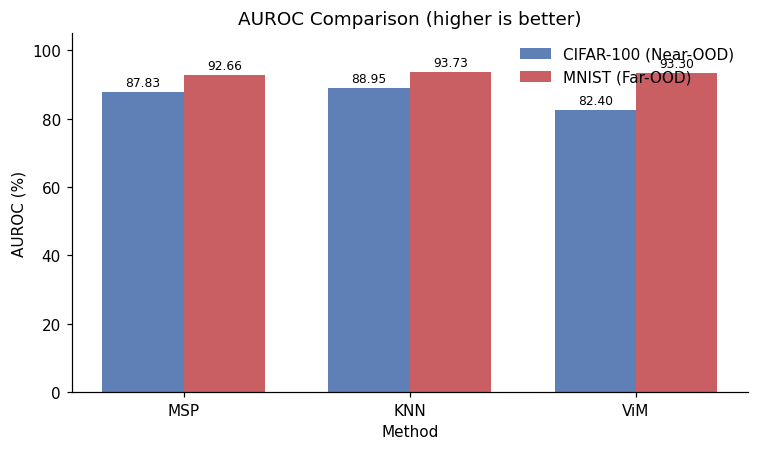

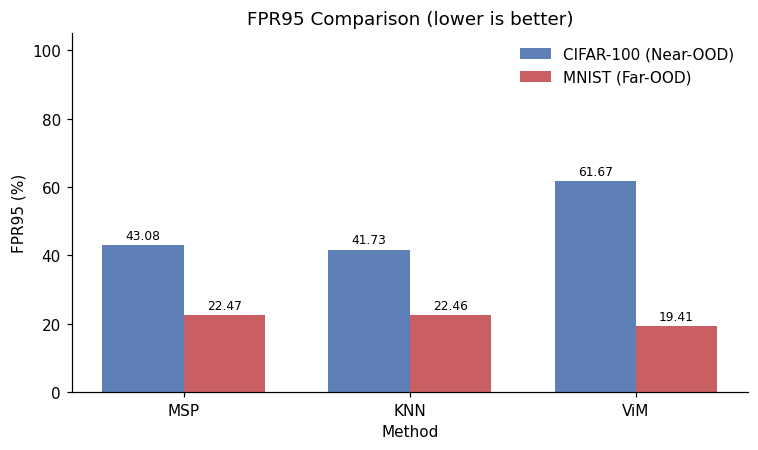

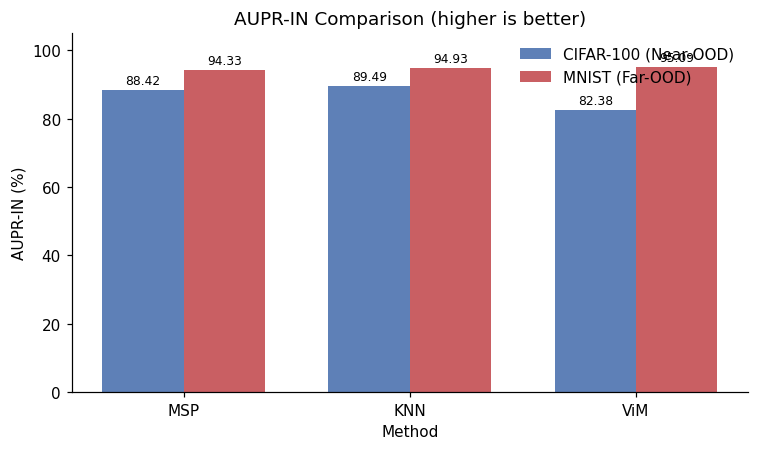

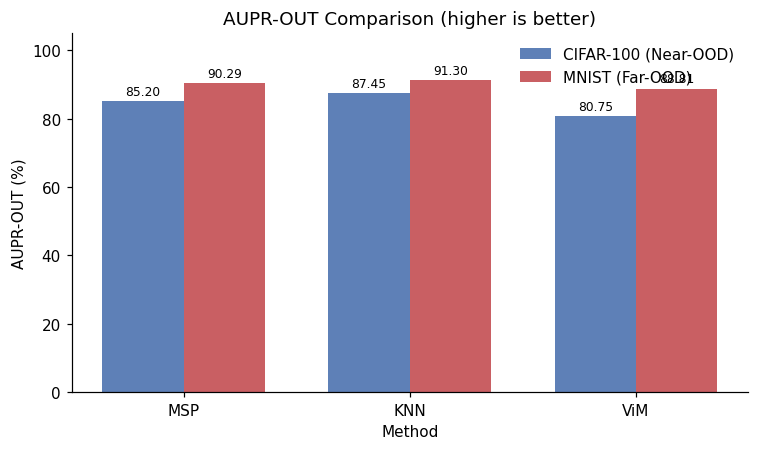

In [ ]:
FIGS = {}
def metric_bar(metric, ylabel, fname, note):
    fig, ax = plt.subplots(figsize=(7, 4.2)); w = 0.36
    x = np.arange(len(METHODS))
    for j, ds in enumerate(DATASETS):
        vals = [comparison_df[(comparison_df.Method == m) & (comparison_df.Dataset == ds)][metric].item() * 100 for m in METHODS]
        b = ax.bar(x + (j - 0.5) * w, vals, w, label=ds, color=['#4C72B0', '#C44E52'][j], alpha=0.9)
        ax.bar_label(b, fmt='%.2f', fontsize=8, padding=2)
    ax.set_xticks(x); ax.set_xticklabels(METHODS); ax.set_xlabel('Method'); ax.set_ylabel(ylabel)
    ax.set_title(f'{metric} Comparison ({note})'); ax.legend(frameon=False)
    ax.set_ylim(0, 105); fig.tight_layout(); fig.savefig(OUT_DIR / fname, dpi=200); plt.show()

metric_bar('AUROC',    'AUROC (%)',    'auroc_comparison.png',    'higher is better')
metric_bar('FPR95',    'FPR95 (%)',    'fpr95_comparison.png',    'lower is better')
metric_bar('AUPR-IN',  'AUPR-IN (%)',  'aupr_in_comparison.png',  'higher is better')
metric_bar('AUPR-OUT', 'AUPR-OUT (%)', 'aupr_out_comparison.png', 'higher is better')

## 7. Near-OOD vs Far-OOD (AUROC)

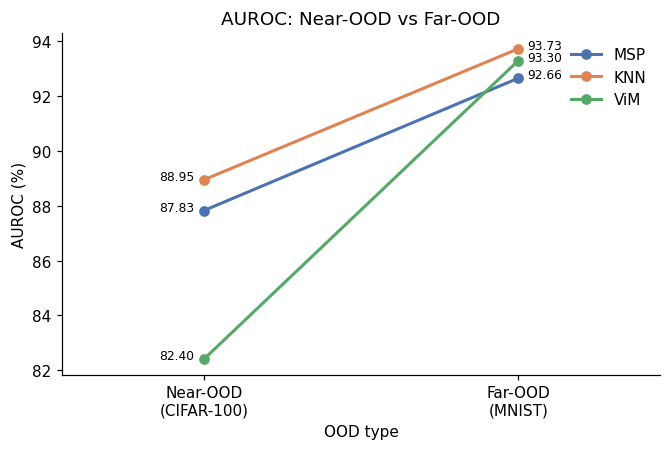

Difference = Far-OOD AUROC - Near-OOD AUROC (pp = percentage points)


,Method,Near-OOD AUROC,Far-OOD AUROC,Difference
0,MSP,87.83,92.66,+4.83 pp
1,KNN,88.95,93.73,+4.79 pp
2,ViM,82.40,93.30,+10.90 pp


In [ ]:
piv = comparison_df.pivot(index='Method', columns='Dataset', values='AUROC').loc[METHODS]
near_far = pd.DataFrame({'Method': METHODS,
                         'Near-OOD AUROC': piv[NEAR].values, 'Far-OOD AUROC': piv[FAR].values})
near_far['Difference'] = near_far['Far-OOD AUROC'] - near_far['Near-OOD AUROC']   # Far - Near

fig, ax = plt.subplots(figsize=(6.2, 4.2))
for m in METHODS:
    r = near_far[near_far.Method == m].iloc[0]
    ax.plot(['Near-OOD\n(CIFAR-100)', 'Far-OOD\n(MNIST)'], [r['Near-OOD AUROC']*100, r['Far-OOD AUROC']*100],
            marker='o', lw=2, color=COLORS[m], label=m)
    ax.annotate(f"{r['Near-OOD AUROC']*100:.2f}", (0, r['Near-OOD AUROC']*100), textcoords='offset points', xytext=(-6, 0), ha='right', fontsize=8)
    ax.annotate(f"{r['Far-OOD AUROC']*100:.2f}",  (1, r['Far-OOD AUROC']*100),  textcoords='offset points', xytext=(6, 0),  ha='left',  fontsize=8)
ax.set_xlim(-0.45, 1.45); ax.set_ylabel('AUROC (%)'); ax.set_xlabel('OOD type'); ax.legend(frameon=False)
ax.set_title('AUROC: Near-OOD vs Far-OOD'); fig.tight_layout(); fig.savefig(OUT_DIR / 'near_vs_far_auroc.png', dpi=200); plt.show()

nf_disp = near_far.copy()
for c in ['Near-OOD AUROC', 'Far-OOD AUROC']: nf_disp[c] = (nf_disp[c]*100).map('{:.2f}'.format)
nf_disp['Difference'] = (near_far['Difference']*100).map('{:+.2f} pp'.format)
print('Difference = Far-OOD AUROC - Near-OOD AUROC (pp = percentage points)'); display(nf_disp)

## 8. Score distributions
Mỗi figure vẽ **raw score ở hướng gốc** của method đó, đúng với interpretation (MSP: cao = ID-like; KNN, ViM: cao = OOD-like).

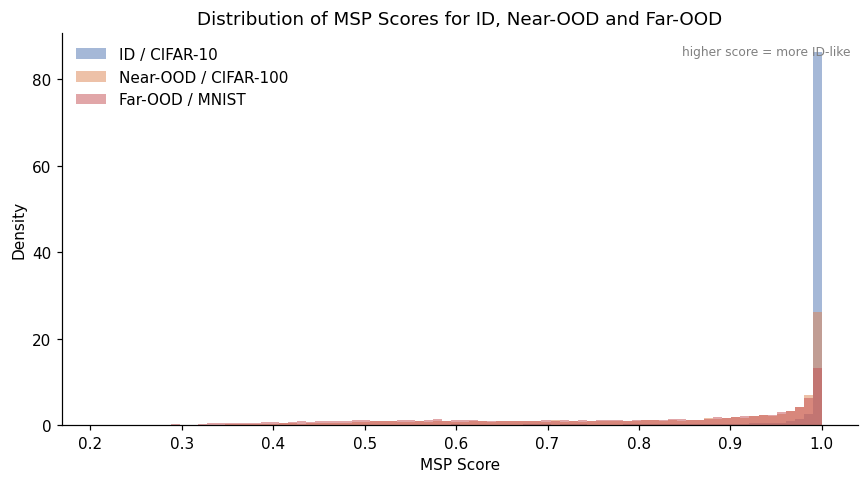

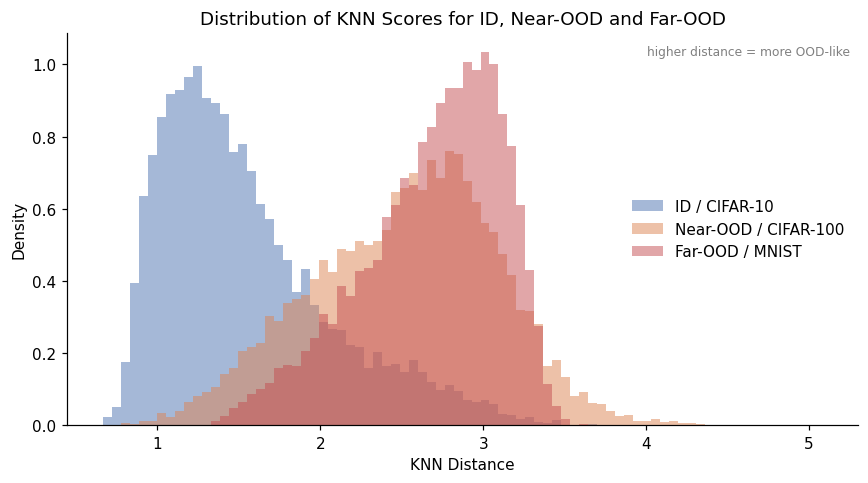

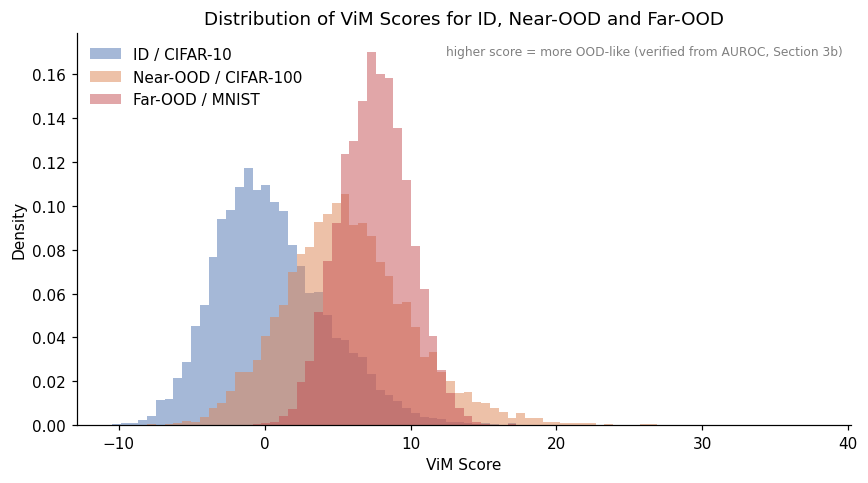

In [ ]:
SPLIT_STYLE = {'ID':  ('ID / CIFAR-10', '#4C72B0'),
               NEAR:  ('Near-OOD / CIFAR-100', '#DD8452'),
               FAR:   ('Far-OOD / MNIST', '#C44E52')}

def dist_plot(m, xlabel, title, fname, direction_note, bins=80):
    allv = np.concatenate([RAW[m][s] for s in SPLIT_STYLE])
    edges = np.linspace(allv.min(), allv.max(), bins + 1)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for s, (lab, col) in SPLIT_STYLE.items():
        ax.hist(RAW[m][s], bins=edges, density=True, alpha=0.5, color=col, label=lab)
    ax.set_xlabel(xlabel); ax.set_ylabel('Density'); ax.set_title(title)
    ax.text(0.99, 0.97, direction_note, transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray')
    ax.legend(frameon=False); fig.tight_layout(); fig.savefig(OUT_DIR / fname, dpi=200); plt.show()

dist_plot('MSP', 'MSP Score', 'Distribution of MSP Scores for ID, Near-OOD and Far-OOD',
          'msp_score_distribution.png', 'higher score = more ID-like')
dist_plot('KNN', 'KNN Distance', 'Distribution of KNN Scores for ID, Near-OOD and Far-OOD',
          'knn_score_distribution.png', 'higher distance = more OOD-like')
dist_plot('ViM', 'ViM Score', 'Distribution of ViM Scores for ID, Near-OOD and Far-OOD',
          'vim_score_distribution.png', 'higher score = more OOD-like (verified from AUROC, Section 3b)')

## 9. ROC curves
Positive = OOD, Negative = ID, OOD-score cao = OOD-like. MSP dùng `1 - MSP`. ROC dựng trực tiếp từ raw score.

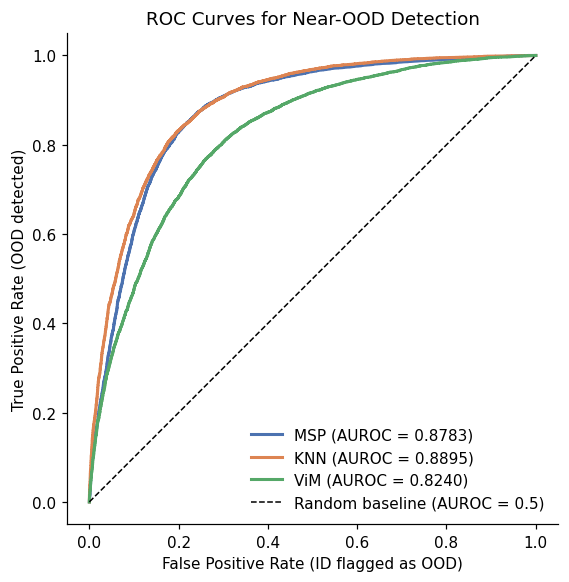

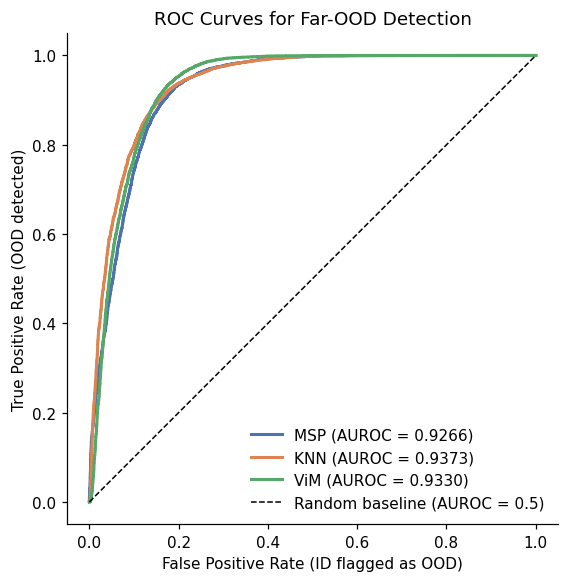

In [ ]:
def roc_plot(split, title, fname):
    fig, ax = plt.subplots(figsize=(5.8, 5.4))
    for m in METHODS:
        i, o = ood_score_01(m, 'ID'), ood_score_01(m, split)
        y = np.r_[np.zeros(len(i)), np.ones(len(o))]; s = np.r_[i, o]
        fpr, tpr, _ = roc_curve(y, s); auc = roc_auc_score(y, s)
        ax.plot(fpr, tpr, color=COLORS[m], lw=2, label=f'{m} (AUROC = {auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline (AUROC = 0.5)')
    ax.set_xlabel('False Positive Rate (ID flagged as OOD)'); ax.set_ylabel('True Positive Rate (OOD detected)')
    ax.set_title(title); ax.legend(loc='lower right', frameon=False); ax.set_aspect('equal')
    fig.tight_layout(); fig.savefig(OUT_DIR / fname, dpi=200); plt.show()

roc_plot(NEAR, 'ROC Curves for Near-OOD Detection', 'roc_near_ood.png')
roc_plot(FAR,  'ROC Curves for Far-OOD Detection',  'roc_far_ood.png')

## 10. Score statistics (descriptive only)
Giá trị là **raw score ở hướng gốc**, nên không so sánh số tuyệt đối giữa các method (khác thang đo). Bảng này không thay thế AUROC.

In [ ]:
rows = []
for m in METHODS:
    for s, (lab, _) in SPLIT_STYLE.items():
        v = RAW[m][s]
        rows.append({'Method': m, 'Dataset': lab, 'Score direction': 'higher = ID-like' if not HIGHER_IS_OOD[m] else 'higher = OOD-like',
                     'N': len(v), 'Mean Score': v.mean(), 'Median Score': np.median(v), 'Std': v.std(ddof=1)})
score_statistics = pd.DataFrame(rows); display(score_statistics.round(4))

,Method,Dataset,Score direction,N,Mean Score,Median Score,Std
0,MSP,ID / CIFAR-10,higher = ID-like,10000,0.9766,0.9999,0.0814
1,MSP,Near-OOD / CIFAR-100,higher = ID-like,10000,0.8321,0.9157,0.1871
2,MSP,Far-OOD / MNIST,higher = ID-like,10000,0.7746,0.8333,0.2044
3,KNN,ID / CIFAR-10,higher = OOD-like,10000,1.5407,1.4184,0.5224
4,KNN,Near-OOD / CIFAR-100,higher = OOD-like,10000,2.5214,2.5716,0.5715
5,KNN,Far-OOD / MNIST,higher = OOD-like,10000,2.6885,2.7612,0.4254
6,ViM,ID / CIFAR-10,higher = OOD-like,10000,0.4522,0.0108,3.8305
7,ViM,Near-OOD / CIFAR-100,higher = OOD-like,10000,5.7131,5.4549,4.3541
8,ViM,Far-OOD / MNIST,higher = OOD-like,10000,7.5098,7.5273,2.3520


## 11. Failure case analysis
**Định nghĩa:** failure = mẫu OOD có OOD-score thấp (trông giống ID). Hardest = OOD-score thấp nhất.

Để so sánh được giữa các method (khác thang đo), mỗi mẫu OOD có thêm **ID-percentile** = % mẫu ID có OOD-score thấp hơn mẫu đó (rất thấp → nằm giữa vùng ID điển hình). Một mẫu bị coi là **missed** nếu OOD-score ≤ ngưỡng giữ lại 95% ID (cùng điểm vận hành TPR95 của FPR95).

**Lưu ý về index:** NPZ chỉ chứa score, không có image index/label/ảnh. `sample_idx` là vị trí trong mảng score. Phần Section 11b kiểm tra thứ tự có aligned giữa 3 method không.

In [ ]:
# Kiem tra alignment thu tu sample giua 3 method (can cho cross-method o Section 11c)
print('Spearman giua OOD-score cua cac method, cung split, cung index (aligned -> duong ro ret; shuffled -> ~0):')
align = []
for s in ['ID', NEAR, FAR]:
    for a, b in [('MSP', 'KNN'), ('MSP', 'ViM'), ('KNN', 'ViM')]:
        align.append({'split': s, 'pair': f'{a}-{b}', 'spearman': spearmanr(ood_score(a, s), ood_score(b, s))[0]})
align = pd.DataFrame(align); display(align.round(3))
ALIGNED = bool((align['spearman'] > 0.3).all())
print('ALIGNED =', ALIGNED)

Spearman giua OOD-score cua cac method, cung split, cung index (aligned -> duong ro ret; shuffled -> ~0):


,split,pair,spearman
0,ID,MSP-KNN,0.597
1,ID,MSP-ViM,0.562
2,ID,KNN-ViM,0.482
3,CIFAR-100 (Near-OOD),MSP-KNN,0.773
4,CIFAR-100 (Near-OOD),MSP-ViM,0.455
5,CIFAR-100 (Near-OOD),KNN-ViM,0.541
6,MNIST (Far-OOD),MSP-KNN,0.888
7,MNIST (Far-OOD),MSP-ViM,0.530
8,MNIST (Far-OOD),KNN-ViM,0.580


ALIGNED = True


In [ ]:
K = 10
thr = {m: np.percentile(ood_score(m, 'ID'), 95) for m in METHODS}   # giu lai 95% ID
def id_pct(m, v):   # % ID co OOD-score thap hon v
    return np.searchsorted(np.sort(ood_score(m, 'ID')), v, side='left') / len(RAW[m]['ID']) * 100

fc_rows = []
for m in METHODS:
    for ds in DATASETS:
        sc = ood_score(m, ds); order = np.argsort(sc)[:K]
        for rank, idx in enumerate(order, 1):
            fc_rows.append({'Method': m, 'Dataset': ds, 'rank (1=hardest)': rank, 'sample_idx': int(idx),
                            'raw_score': RAW[m][ds][idx], 'ID_percentile': id_pct(m, sc[idx]),
                            'missed@TPR95': bool(sc[idx] <= thr[m])})
failure_cases = pd.DataFrame(fc_rows)
print(f'Top-{K} OOD kho phat hien nhat cho moi (method, dataset):'); display(failure_cases.round(4))

print('\nTy le OOD bi miss (OOD-score <= nguong giu 95% ID):')
miss = pd.DataFrame([{'Method': m, 'Dataset': ds, 'missed rate (%)': (ood_score(m, ds) <= thr[m]).mean()*100} for m in METHODS for ds in DATASETS])
display(miss.round(2))

Top-10 OOD kho phat hien nhat cho moi (method, dataset):


,Method,Dataset,rank (1=hardest),sample_idx,raw_score,ID_percentile,missed@TPR95
0,MSP,CIFAR-100 (Near-OOD),1,9957,1.0000,1.81,True
1,MSP,CIFAR-100 (Near-OOD),2,4173,1.0000,1.81,True
2,MSP,CIFAR-100 (Near-OOD),3,4678,1.0000,2.19,True
3,MSP,CIFAR-100 (Near-OOD),4,5307,1.0000,2.19,True
4,MSP,CIFAR-100 (Near-OOD),5,6339,1.0000,3.10,True
5,MSP,CIFAR-100 (Near-OOD),6,3792,1.0000,4.06,True
6,MSP,CIFAR-100 (Near-OOD),7,4308,1.0000,4.18,True
7,MSP,CIFAR-100 (Near-OOD),8,2374,1.0000,4.45,True
8,MSP,CIFAR-100 (Near-OOD),9,3026,1.0000,4.45,True
9,MSP,CIFAR-100 (Near-OOD),10,12,1.0000,4.60,True



Ty le OOD bi miss (OOD-score <= nguong giu 95% ID):


,Method,Dataset,missed rate (%)
0,MSP,CIFAR-100 (Near-OOD),62.91
1,MSP,MNIST (Far-OOD),51.47
2,KNN,CIFAR-100 (Near-OOD),53.68
3,KNN,MNIST (Far-OOD),38.51
4,ViM,CIFAR-100 (Near-OOD),67.39
5,ViM,MNIST (Far-OOD),45.85


### 11c. Cross-method failure cases (disagreement)
Với mỗi mẫu OOD, mỗi method cho kết luận **detected** (OOD-score > ngưỡng giữ 95% ID) hoặc **missed**. Bảng chỉ gồm mẫu mà các method **bất đồng**, ưu tiên mức bất đồng lớn (chênh lệch ID-percentile giữa method tốt nhất và tệ nhất), cùng các mẫu cả 3 đều missed.

Cột `Interpretation` chỉ mô tả cơ chế từ số liệu (percentile của từng method); **không** phải giải thích về nội dung ảnh, vì không có ảnh trong file.

In [ ]:
def cross_table(ds, n_each=8):
    idx = np.arange(len(RAW['MSP'][ds]))
    df = pd.DataFrame({'sample_idx': idx})
    for m in METHODS:
        sc = ood_score(m, ds)
        df[f'{m}_pct'] = id_pct(m, sc)
        df[f'{m}_detected'] = sc > thr[m]
    df['n_detected'] = df[[f'{m}_detected' for m in METHODS]].sum(axis=1)
    pc = df[[f'{m}_pct' for m in METHODS]]
    df['spread'] = pc.max(axis=1) - pc.min(axis=1)
    return df

def interpret(r):
    pcts = {m: r[f'{m}_pct'] for m in METHODS}
    det = [m for m in METHODS if r[f'{m}_detected']]; mis = [m for m in METHODS if not r[f'{m}_detected']]
    hi, lo = max(pcts, key=pcts.get), min(pcts, key=pcts.get)
    if not det: return f'All methods miss (lowest ID-percentile: {lo} {pcts[lo]:.1f}%).'
    return (f"{'/'.join(det)} detect, {'/'.join(mis)} miss: {hi} places it at ID-percentile {pcts[hi]:.1f}% "
            f"vs {lo} at {pcts[lo]:.1f}% (spread {pcts[hi]-pcts[lo]:.1f} pp).")

cross_rows = []
if not ALIGNED:
    print('Thu tu sample KHONG aligned giua cac method -> bo qua phan cross-method (se khong so sanh sai sample).')
else:
    for ds in DATASETS:
        t = cross_table(ds)
        disagree = t[(t.n_detected > 0) & (t.n_detected < 3)].sort_values('spread', ascending=False).head(12)
        all_miss = t[t.n_detected == 0].assign(_m=lambda d: d[[f'{m}_pct' for m in METHODS]].mean(axis=1)).sort_values('_m').head(4)
        print(f'\n{ds}: disagreement = {((t.n_detected>0)&(t.n_detected<3)).sum()}, all-3-missed = {(t.n_detected==0).sum()}, all-3-detected = {(t.n_detected==3).sum()}  (/{len(t)})')
        for kind, sub in [('disagreement', disagree), ('all methods miss', all_miss)]:
            for _, r in sub.iterrows():
                cross_rows.append({'Sample': f"{ds.split()[0]}#{int(r.sample_idx)}",
                    'MSP': 'detected' if r.MSP_detected else 'MISSED', 'KNN': 'detected' if r.KNN_detected else 'MISSED',
                    'ViM': 'detected' if r.ViM_detected else 'MISSED', 'Ground Truth': f'OOD ({ds})',
                    'MSP ID-pct': r.MSP_pct, 'KNN ID-pct': r.KNN_pct, 'ViM ID-pct': r.ViM_pct,
                    'Type': kind, 'Interpretation': interpret(r)})
    cross_df = pd.DataFrame(cross_rows)
    pd.set_option('display.max_colwidth', 120)
    display(cross_df.round(1))

    # tong hop: moi cap method bat dong bao nhieu mau
    print('\nSo mau OOD ma method A detected nhung method B missed:')
    summ = []
    for ds in DATASETS:
        t = cross_table(ds)
        for a in METHODS:
            for b in METHODS:
                if a != b: summ.append({'Dataset': ds, 'A detects': a, 'B misses': b, 'n': int((t[f'{a}_detected'] & ~t[f'{b}_detected']).sum())})
    display(pd.DataFrame(summ).pivot_table(index=['Dataset', 'A detects'], columns='B misses', values='n', fill_value=0))


CIFAR-100 (Near-OOD): disagreement = 4449, all-3-missed = 3941, all-3-detected = 1610  (/10000)

MNIST (Far-OOD): disagreement = 3889, all-3-missed = 2667, all-3-detected = 3444  (/10000)


,Sample,MSP,KNN,ViM,Ground Truth,MSP ID-pct,KNN ID-pct,ViM ID-pct,Type,Interpretation
0,CIFAR-100#7032,MISSED,detected,MISSED,OOD (CIFAR-100 (Near-OOD)),5.1,98.8,31.0,disagreement,"KNN detect, MSP/ViM miss: KNN places it at ID-percentile 98.8% vs MSP at 5.1% (spread 93.8 pp)."
1,CIFAR-100#2047,MISSED,detected,MISSED,OOD (CIFAR-100 (Near-OOD)),93.8,96.4,13.3,disagreement,"KNN detect, MSP/ViM miss: KNN places it at ID-percentile 96.4% vs ViM at 13.3% (spread 83.1 pp)."
2,CIFAR-100#4095,MISSED,MISSED,detected,OOD (CIFAR-100 (Near-OOD)),39.1,14.4,97.5,disagreement,"ViM detect, MSP/KNN miss: ViM places it at ID-percentile 97.5% vs KNN at 14.4% (spread 83.1 pp)."
3,CIFAR-100#5690,MISSED,MISSED,detected,OOD (CIFAR-100 (Near-OOD)),16.0,80.5,97.0,disagreement,"ViM detect, MSP/KNN miss: ViM places it at ID-percentile 97.0% vs MSP at 16.0% (spread 81.0 pp)."
4,CIFAR-100#528,MISSED,detected,MISSED,OOD (CIFAR-100 (Near-OOD)),21.4,98.1,17.4,disagreement,"KNN detect, MSP/ViM miss: KNN places it at ID-percentile 98.1% vs ViM at 17.4% (spread 80.7 pp)."
5,CIFAR-100#7679,MISSED,detected,MISSED,OOD (CIFAR-100 (Near-OOD)),16.2,96.9,87.1,disagreement,"KNN detect, MSP/ViM miss: KNN places it at ID-percentile 96.9% vs MSP at 16.2% (spread 80.7 pp)."
6,CIFAR-100#4299,MISSED,detected,MISSED,OOD (CIFAR-100 (Near-OOD)),87.7,96.4,15.8,disagreement,"KNN detect, MSP/ViM miss: KNN places it at ID-percentile 96.4% vs ViM at 15.8% (spread 80.5 pp)."
7,CIFAR-100#5777,MISSED,MISSED,detected,OOD (CIFAR-100 (Near-OOD)),20.2,84.7,99.5,disagreement,"ViM detect, MSP/KNN miss: ViM places it at ID-percentile 99.5% vs MSP at 20.2% (spread 79.3 pp)."
8,CIFAR-100#255,detected,MISSED,MISSED,OOD (CIFAR-100 (Near-OOD)),96.9,89.2,17.9,disagreement,"MSP detect, KNN/ViM miss: MSP places it at ID-percentile 96.9% vs ViM at 17.9% (spread 79.0 pp)."
9,CIFAR-100#8723,MISSED,detected,detected,OOD (CIFAR-100 (Near-OOD)),18.4,97.4,97.0,disagreement,"KNN/ViM detect, MSP miss: KNN places it at ID-percentile 97.4% vs MSP at 18.4% (spread 79.0 pp)."



So mau OOD ma method A detected nhung method B missed:


B misses                           KNN     MSP     ViM
Dataset              A detects                        
CIFAR-100 (Near-OOD) KNN           0.0  1535.0  2321.0
                     MSP         612.0     0.0  1964.0
                     ViM         950.0  1516.0     0.0
MNIST (Far-OOD)      KNN           0.0  1485.0  1847.0
                     MSP         189.0     0.0  1291.0
                     ViM        1113.0  1853.0     0.0

## 12. Overall summary
**Methodology:** không tạo "overall score" bằng cách trung bình metric (hướng tốt/xấu khác nhau, thang khác nhau). Thay vào đó:
1. **Rank theo từng metric** riêng (1 = tốt nhất; AUROC/AUPR cao tốt hơn, FPR95/AUTC thấp tốt hơn), theo từng dataset.
2. **Overall** = rank theo AUROC trung bình của Near và Far (trung bình 2 AUROC cùng chiều, cùng thang) và kèm số metric mà method đứng nhất, để người đọc tự đánh giá.
Không có weighting, nên Near và Far được coi ngang nhau. Đây là lựa chọn của phân tích, không phải chuẩn.

In [ ]:
HIGHER_BETTER = {'AUROC': True, 'AUPR-IN': True, 'AUPR-OUT': True, 'FPR95': False, 'AUTC': False}
rank_rows = []
for ds in DATASETS:
    sub = comparison_df[comparison_df.Dataset == ds].set_index('Method')
    for met in METRICS:
        rk = sub[met].rank(ascending=not HIGHER_BETTER[met], method='min').astype(int)
        for m in METHODS: rank_rows.append({'Dataset': ds, 'Metric': met, 'Method': m, 'Rank': rk[m]})
rank_df = pd.DataFrame(rank_rows)
print('Rank theo tung metric (1 = tot nhat):')
display(rank_df.pivot_table(index=['Dataset', 'Metric'], columns='Method', values='Rank')[METHODS])

wins = rank_df[rank_df.Rank == 1].groupby(['Dataset', 'Method']).size().unstack(fill_value=0).reindex(columns=METHODS, fill_value=0)
print('So metric dung hang 1 (tren 5 metric):'); display(wins)

auroc = near_far.set_index('Method')
mean_auroc = (auroc['Near-OOD AUROC'] + auroc['Far-OOD AUROC']) / 2
def rk_auroc(col): return auroc[col].rank(ascending=False, method='min').astype(int)
overall = pd.DataFrame({'Method': METHODS,
    'Near-OOD (AUROC rank)': [f"{rk_auroc('Near-OOD AUROC')[m]} ({auroc.loc[m,'Near-OOD AUROC']*100:.2f}%)" for m in METHODS],
    'Far-OOD (AUROC rank)':  [f"{rk_auroc('Far-OOD AUROC')[m]} ({auroc.loc[m,'Far-OOD AUROC']*100:.2f}%)" for m in METHODS],
    'Overall (rank of mean AUROC)': [f"{int(mean_auroc.rank(ascending=False, method='min')[m])} ({mean_auroc[m]*100:.2f}%)" for m in METHODS]})
display(overall)

Rank theo tung metric (1 = tot nhat):


Method                         MSP  KNN  ViM
Dataset              Metric                 
CIFAR-100 (Near-OOD) AUPR-IN   2.0  1.0  3.0
                     AUPR-OUT  2.0  1.0  3.0
                     AUROC     2.0  1.0  3.0
                     AUTC      2.0  1.0  3.0
                     FPR95     2.0  1.0  3.0
MNIST (Far-OOD)      AUPR-IN   3.0  2.0  1.0
                     AUPR-OUT  2.0  1.0  3.0
                     AUROC     3.0  1.0  2.0
                     AUTC      2.0  1.0  3.0
                     FPR95     3.0  2.0  1.0

So metric dung hang 1 (tren 5 metric):


Method,MSP,KNN,ViM
Dataset,,,
CIFAR-100 (Near-OOD),0,5,0
MNIST (Far-OOD),0,3,2


,Method,Near-OOD (AUROC rank),Far-OOD (AUROC rank),Overall (rank of mean AUROC)
0,MSP,2 (87.83%),3 (92.66%),2 (90.24%)
1,KNN,1 (88.95%),1 (93.73%),1 (91.34%)
2,ViM,3 (82.40%),2 (93.30%),3 (87.85%)


### Final summary table (thesis)
`Type` và `Main Information Used` được điền theo dữ liệu thực tế trong file: MSP lưu `msp_*` (max softmax probability), KNN lưu khoảng cách (giá trị 0.67–5.08, tức khoảng cách trong feature space), ViM lưu score có thể âm (kết hợp feature residual và logit). Các file NPZ **không** chứa chi tiết hyperparameter (k, số chiều principal space, layer lấy feature). Bạn nên bổ sung thủ công từ notebook gốc nếu cần ghi vào thesis.

In [ ]:
TYPE_INFO = {'MSP': ('Confidence-based', 'Softmax probabilities'),
             'KNN': ('Feature-based', 'Feature-space distance'),
             'ViM': ('Feature/Logit-based', 'Feature + logit information')}
def g(m, ds, met): return comparison_df[(comparison_df.Method == m) & (comparison_df.Dataset == ds)][met].item() * 100
final_summary = pd.DataFrame([{'Method': m, 'Type': TYPE_INFO[m][0], 'Main Information Used': TYPE_INFO[m][1],
    'Near-OOD AUROC (%)': round(g(m, NEAR, 'AUROC'), 2), 'Far-OOD AUROC (%)': round(g(m, FAR, 'AUROC'), 2),
    'Near-OOD FPR95 (%)': round(g(m, NEAR, 'FPR95'), 2), 'Far-OOD FPR95 (%)': round(g(m, FAR, 'FPR95'), 2)} for m in METHODS])
display(final_summary)

,Method,Type,Main Information Used,Near-OOD AUROC (%),Far-OOD AUROC (%),Near-OOD FPR95 (%),Far-OOD FPR95 (%)
0,MSP,Confidence-based,Softmax probabilities,87.83,92.66,43.08,22.47
1,KNN,Feature-based,Feature-space distance,88.95,93.73,41.73,22.46
2,ViM,Feature/Logit-based,Feature + logit information,82.40,93.30,61.67,19.41


## 13. Save outputs

In [ ]:
comparison_metrics = comparison_df.copy()
for c in METRICS: comparison_metrics[c] = comparison_metrics[c] * 100
comparison_metrics = comparison_metrics.rename(columns={c: f'{c} (%)' for c in METRICS})
comparison_metrics.to_csv(OUT_DIR / 'comparison_metrics.csv', index=False)
final_summary.to_csv(OUT_DIR / 'comparison_summary.csv', index=False)
near_far.assign(**{c: near_far[c]*100 for c in ['Near-OOD AUROC', 'Far-OOD AUROC', 'Difference']}).to_csv(OUT_DIR / 'near_vs_far_auroc.csv', index=False)
overall.to_csv(OUT_DIR / 'overall_ranking.csv', index=False)
rank_df.to_csv(OUT_DIR / 'metric_ranks.csv', index=False)
score_statistics.to_csv(OUT_DIR / 'score_statistics.csv', index=False)
failure_cases.to_csv(OUT_DIR / 'failure_cases.csv', index=False)
if ALIGNED and cross_rows: pd.DataFrame(cross_rows).to_csv(OUT_DIR / 'cross_method_failure_cases.csv', index=False)

expected = ['comparison_metrics.csv', 'comparison_summary.csv', 'auroc_comparison.png', 'fpr95_comparison.png',
            'aupr_in_comparison.png', 'aupr_out_comparison.png', 'near_vs_far_auroc.png', 'msp_score_distribution.png',
            'knn_score_distribution.png', 'vim_score_distribution.png', 'roc_near_ood.png', 'roc_far_ood.png',
            'score_statistics.csv', 'failure_cases.csv']
missing = [f for f in expected if not (OUT_DIR / f).exists()]
print('Saved to', OUT_DIR); print(sorted(p.name for p in OUT_DIR.iterdir()))
assert not missing, f'Thieu output: {missing}'

# Tuy chon: tai xuong tren Colab
# from google.colab import files; import shutil; shutil.make_archive('/content/ood_outputs','zip',OUT_DIR); files.download('/content/ood_outputs.zip')

Saved to /content/ood_comparison_outputs
['aupr_in_comparison.png', 'aupr_out_comparison.png', 'auroc_comparison.png', 'comparison_metrics.csv', 'comparison_summary.csv', 'cross_method_failure_cases.csv', 'failure_cases.csv', 'fpr95_comparison.png', 'knn_score_distribution.png', 'metric_ranks.csv', 'msp_score_distribution.png', 'near_vs_far_auroc.csv', 'near_vs_far_auroc.png', 'overall_ranking.csv', 'roc_far_ood.png', 'roc_near_ood.png', 'score_statistics.csv', 'vim_score_distribution.png']
